In [ ]:
# =========================================================
# ARTIFICIAL NEURAL NETWORK PROJECT
# Iris Flower Classification using TensorFlow/Keras
# Demonstrates:
# - Forward Propagation
# - Backward Propagation
# - Activation Functions
# - Optimizer Comparison
# =========================================================


In [1]:
# =========================================================
# 1. Import Required Libraries
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and preprocessing tools
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Deep Learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# =========================================================
# 2. Load the Iris Dataset
# =========================================================
# Iris dataset contains 150 samples of flowers
# Each sample has 4 features:
# - sepal length
# - sepal width
# - petal length
# - petal width
#
# Target classes:
# 0 = Setosa
# 1 = Versicolor
# 2 = Virginica

iris = load_iris()

# Convert dataset to pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target label column
df["species"] = iris.target

print("Dataset shape:", df.shape)
df.head()



Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# =========================================================
# 3. Separate Features and Labels
# =========================================================

# Features (input)
X = df.drop("species", axis=1)

# Labels (output)
y = df["species"]

# Convert labels to one-hot encoding
# Example: 1 -> [0 1 0]
y_categorical = to_categorical(y)

print("Flower classes:", iris.target_names)


Flower classes: ['setosa' 'versicolor' 'virginica']


In [8]:
# =========================================================
# 4. Normalize Features
# =========================================================
# Neural networks work better when features are scaled

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train/Test split done:
X_train: (120, 4) X_test: (30, 4)


In [9]:
# =========================================================
# 5. Split Dataset into Train and Test
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_categorical,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (120, 4)
Testing samples: (30, 4)


In [10]:
# =========================================================
# 6. Function to Build ANN Model
# =========================================================
# This function allows testing different
# activation functions and optimizers

def build_model(activation_function, optimizer_name):

    model = Sequential([

        # Input layer
        Input(shape=(X_train.shape[1],)),

        # Hidden Layer 1
        Dense(16, activation=activation_function),

        # Hidden Layer 2
        Dense(8, activation=activation_function),

        # Output layer (3 classes)
        Dense(3, activation="softmax")
    ])

    # Compile model
    model.compile(
        optimizer=optimizer_name,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Model builder ready!")



Model builder ready!


In [22]:
# =========================================================
# 7. Train Models with Different Activations & Optimizers
# =========================================================

activations = ["relu", "tanh", "sigmoid"]
optimizers = ["adam", "sgd", "rmsprop"]

# Store results
histories = {}
accuracies = {}

best_model = None
best_score = 0        # Best validation accuracy
best_loss = float('inf')  # To break ties using lowest validation loss
best_config = None


for act in activations:
    for opt in optimizers:

        config = f"{act}-{opt}"

        print("\n===================================")
        print("Training Model:", config)
        print("===================================")

        model = build_model(act, opt)

        # Early stopping prevents overfitting
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        # Train model (forward + backward propagation)
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=8,
            callbacks=[early_stop],
            verbose=0
        )

        # Store history
        histories[config] = history

        # Extract metrics
        train_acc = max(history.history["accuracy"])
        val_acc = max(history.history["val_accuracy"])

        train_loss = min(history.history["loss"])
        val_loss = min(history.history["val_loss"])

        # Print results for each model
        print("Training Accuracy :", round(train_acc,4))
        print("Validation Accuracy :", round(val_acc,4))
        print("Training Loss :", round(train_loss,4))
        print("Validation Loss :", round(val_loss,4))

        # Track best model:
        # 1️⃣ First by validation accuracy
        # 2️⃣ If tie, by lowest validation loss
        if (val_acc > best_score) or (val_acc == best_score and val_loss < best_loss):
            best_score = val_acc
            best_loss = val_loss
            best_model = model
            best_config = config


print("\n==============================")
print("Best Model Configuration:", best_config)
print("Best Validation Accuracy:", round(best_score,4))
print("Best Validation Loss:", round(best_loss,4))
print("==============================")


Training Model: relu-adam
Training Accuracy : 0.9833
Validation Accuracy : 1.0
Training Loss : 0.0624
Validation Loss : 0.0403

Training Model: relu-sgd
Training Accuracy : 0.975
Validation Accuracy : 1.0
Training Loss : 0.1103
Validation Loss : 0.0807

Training Model: relu-rmsprop
Training Accuracy : 0.9833
Validation Accuracy : 1.0
Training Loss : 0.0599
Validation Loss : 0.0326

Training Model: tanh-adam
Training Accuracy : 0.9833
Validation Accuracy : 1.0
Training Loss : 0.068
Validation Loss : 0.0454

Training Model: tanh-sgd
Training Accuracy : 0.9667
Validation Accuracy : 1.0
Training Loss : 0.1317
Validation Loss : 0.0981

Training Model: tanh-rmsprop
Training Accuracy : 0.9833
Validation Accuracy : 1.0
Training Loss : 0.0583
Validation Loss : 0.0362

Training Model: sigmoid-adam
Training Accuracy : 0.9583
Validation Accuracy : 0.9667
Training Loss : 0.2549
Validation Loss : 0.2383

Training Model: sigmoid-sgd
Training Accuracy : 0.85
Validation Accuracy : 0.9333
Training Loss

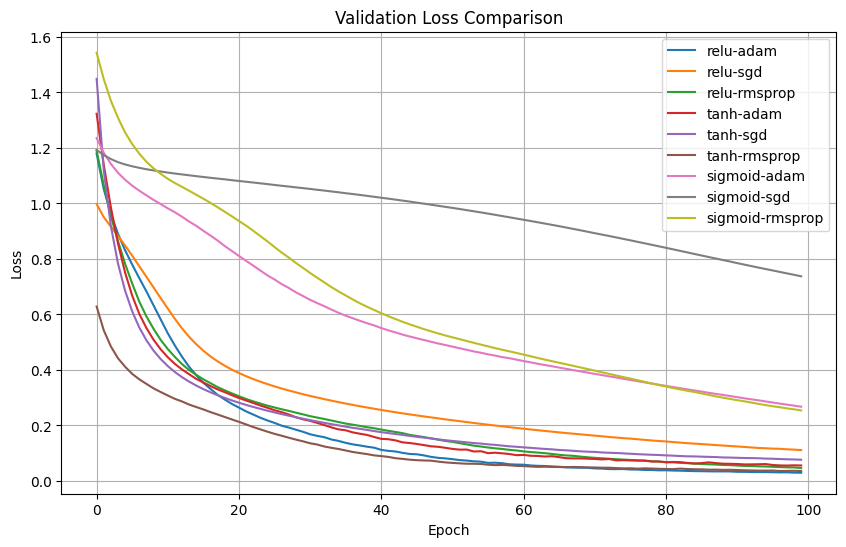

In [12]:
# =========================================================
# 8. Plot Validation Loss for All Configurations
# =========================================================

plt.figure(figsize=(10,6))

for config in histories:
    plt.plot(histories[config].history["val_loss"], label=config)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


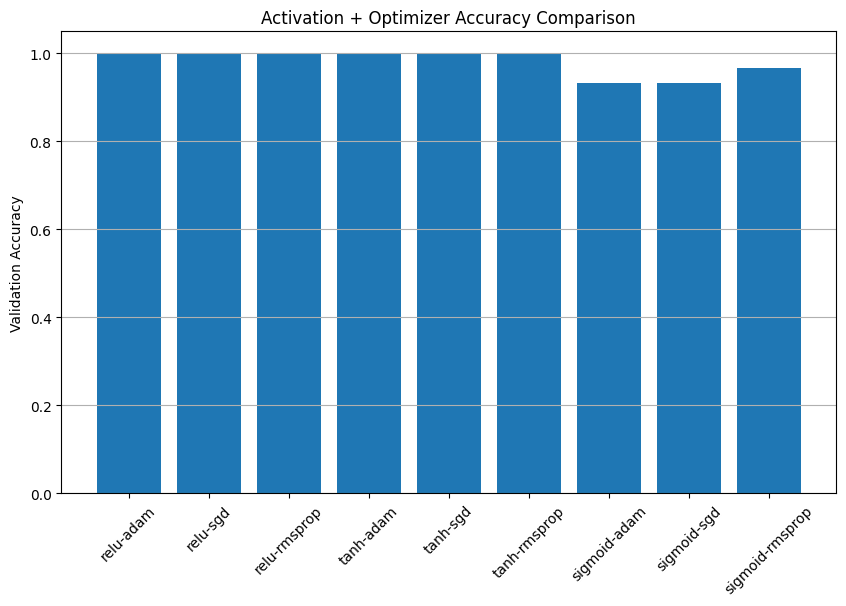

In [13]:
# =========================================================
# 9. Compare Validation Accuracy
# =========================================================

plt.figure(figsize=(10,6))

plt.bar(accuracies.keys(), accuracies.values())

plt.xticks(rotation=45)

plt.title("Activation + Optimizer Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.grid(axis="y")

plt.show()


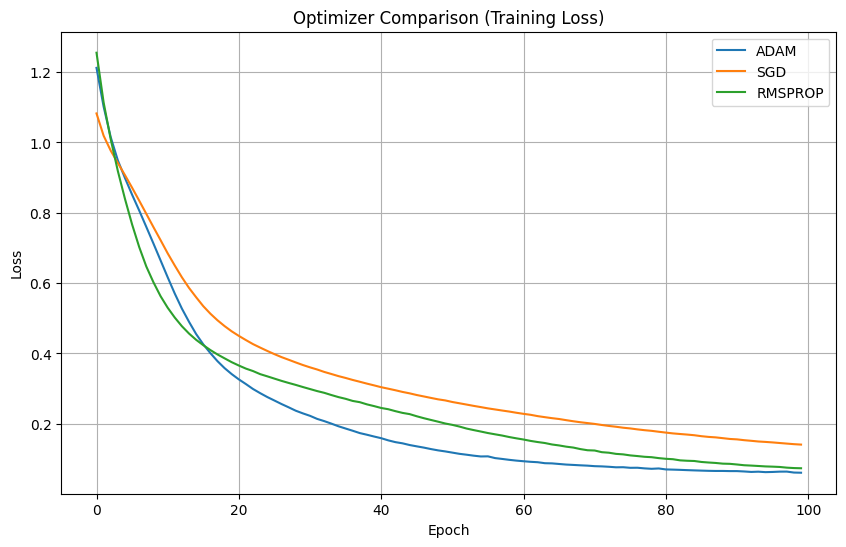

In [14]:
# =========================================================
# 10. Optimizer Training Loss Visualization
# =========================================================
# Shows how optimizers converge

plt.figure(figsize=(10,6))

for config in histories:

    act, opt = config.split("-")

    # Only show RELU optimizer comparison
    if act == "relu":

        plt.plot(
            histories[config].history["loss"],
            label=opt.upper()
        )

plt.title("Optimizer Comparison (Training Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
# =========================================================
# 11. Evaluate Best Model
# =========================================================

y_pred_prob = best_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


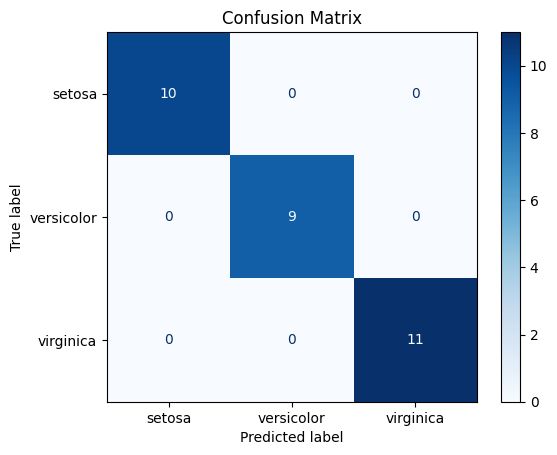

In [16]:
# 12. Confusion Matrix
# =========================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [17]:
# =========================================================
# 13. Classification Report
# =========================================================

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
# =========================================================
# Manual Hard-coded Prediction
# ---------------------------------------------------------
# Provide a custom flower measurement and let the model
# predict which Iris species it belongs to.
# =========================================================

custom_values = [5.1, 3.5, 1.4, 0.2]

custom_input = np.array(custom_values).reshape(1, -1)

# Apply same scaling used during training
custom_input_scaled = scaler.transform(custom_input)

prediction = best_model.predict(custom_input_scaled)

predicted_index = np.argmax(prediction)

predicted_label = iris.target_names[predicted_index]

print("\n==============================")
print(" Iris Flower Prediction ")
print("==============================")

print("\nGiven Input:")

for name, val in zip(X.columns, custom_values):
    print(f"{name}: {val}")

print("\nPredicted Flower:", predicted_label)

print("\nPrediction Probabilities:")

for cls, prob in zip(iris.target_names, prediction[0]):
    print(f"{cls}: {prob:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step

 Iris Flower Prediction 

Given Input:
sepal length (cm): 5.1
sepal width (cm): 3.5
petal length (cm): 1.4
petal width (cm): 0.2

Predicted Flower: setosa

Prediction Probabilities:
setosa: 0.9996
versicolor: 0.0004
virginica: 0.0000


3759/3759 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


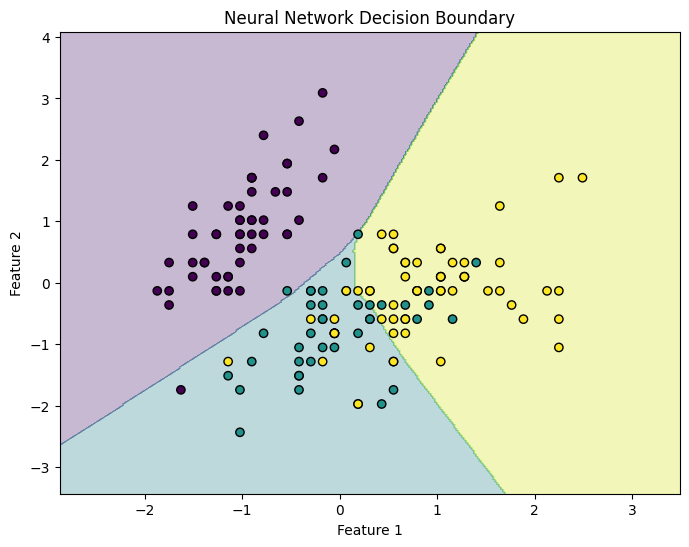

In [20]:
# =========================================================
# 15. Decision Boundary Visualization
# =========================================================
# Use only first two features for visualization

X_vis = X_scaled[:, :2]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_categorical,
    test_size=0.2,
    random_state=42
)

model_vis = Sequential([
    Input(shape=(2,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

model_vis.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_vis.fit(X_train_vis, y_train_vis, epochs=100, verbose=0)

# Create mesh grid
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred = model_vis.predict(grid)

pred = np.argmax(pred, axis=1)
pred = pred.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, pred, alpha=0.3)

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y,
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("Neural Network Decision Boundary")

plt.show()